<a href="https://colab.research.google.com/github/veronicaluzzi/Data-Science-Cohort-20/blob/main/Project-4/Project_4_Spotify.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn import datasets
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error


## Read in Data

In [ ]:
url = "https://ddc-datascience.s3.amazonaws.com/Projects/Project.4-Spotify/Data/Spotify.csv"
url

'https://ddc-datascience.s3.amazonaws.com/Projects/Project.4-Spotify/Data/Spotify.csv'

In [ ]:
!curl -s -I {url}

HTTP/1.1 200 OK
x-amz-id-2: DYXsufH+y1m6B/7Z/rmGrJdST8OZ0favy9oTFLFVm7GyvPeBWPENjopFrSU8omXruwc3+h9EOIUq43GnFwfZf50uiLnhTczH
x-amz-request-id: GCVSXW7R21ZQYEYA
Date: Thu, 14 May 2026 19:33:11 GMT
Last-Modified: Wed, 04 Oct 2023 17:23:56 GMT
ETag: "65b9875b11e0d7ea03ee2af024f45e99"
x-amz-server-side-encryption: AES256
Accept-Ranges: bytes
Content-Type: text/csv
Content-Length: 738124
Server: AmazonS3



In [ ]:
!curl -s  {url}| head -10 | cat -n

     1	Index,Highest Charting Position,Number of Times Charted,Week of Highest Charting,Song Name,Streams,Artist,Artist Followers,Song ID,Genre,Release Date,Weeks Charted,Popularity,Danceability,Energy,Loudness,Speechiness,Acousticness,Liveness,Tempo,Duration (ms),Valence,Chord
     2	1,1,8,2021-07-23--2021-07-30,Beggin',"48,633,449",Måneskin,3377762,3Wrjm47oTz2sjIgck11l5e,"['indie rock italiano', 'italian pop']",2017-12-08,"2021-07-23--2021-07-30
     3	2021-07-16--2021-07-23
     4	2021-07-09--2021-07-16
     5	2021-07-02--2021-07-09
     6	2021-06-25--2021-07-02
     7	2021-06-18--2021-06-25
     8	2021-06-11--2021-06-18
     9	2021-06-04--2021-06-11",100,0.714,0.8,-4.808,0.0504,0.127,0.359,134.002,211560,0.589,B
    10	2,2,3,2021-07-23--2021-07-30,STAY (with Justin Bieber),"47,248,719",The Kid LAROI,2230022,5HCyWlXZPP0y6Gqq8TgA20,['australian hip hop'],2021-07-09,"2021-07-23--2021-07-30


In [ ]:
#spotify = pd.read_csv( url, index_col = 0 )#this makes the index 0 column my index column.  In this case, I do not want to do that.


In [ ]:
spotify = pd.read_csv(url)
spotify

,Index,Highest Charting Position,Number of Times Charted,Week of Highest Charting,Song Name,Streams,Artist,Artist Followers,Song ID,Genre,...,Danceability,Energy,Loudness,Speechiness,Acousticness,Liveness,Tempo,Duration (ms),Valence,Chord
0,1,1,8,2021-07-23--2021-07-30,Beggin',"48,633,449",Måneskin,3377762,3Wrjm47oTz2sjIgck11l5e,"['indie rock italiano', 'italian pop']",...,0.714,0.8,-4.808,0.0504,0.127,0.359,134.002,211560,0.589,B
1,2,2,3,2021-07-23--2021-07-30,STAY (with Justin Bieber),"47,248,719",The Kid LAROI,2230022,5HCyWlXZPP0y6Gqq8TgA20,['australian hip hop'],...,0.591,0.764,-5.484,0.0483,0.0383,0.103,169.928,141806,0.478,C#/Db
2,3,1,11,2021-06-25--2021-07-02,good 4 u,"40,162,559",Olivia Rodrigo,6266514,4ZtFanR9U6ndgddUvNcjcG,['pop'],...,0.563,0.664,-5.044,0.154,0.335,0.0849,166.928,178147,0.688,A
3,4,3,5,2021-07-02--2021-07-09,Bad Habits,"37,799,456",Ed Sheeran,83293380,6PQ88X9TkUIAUIZJHW2upE,"['pop', 'uk pop']",...,0.808,0.897,-3.712,0.0348,0.0469,0.364,126.026,231041,0.591,B
4,5,5,1,2021-07-23--2021-07-30,INDUSTRY BABY (feat. Jack Harlow),"33,948,454",Lil Nas X,5473565,27NovPIUIRrOZoCHxABJwK,"['lgbtq+ hip hop', 'pop rap']",...,0.736,0.704,-7.409,0.0615,0.0203,0.0501,149.995,212000,0.894,D#/Eb
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1551,1552,195,1,2019-12-27--2020-01-03,New Rules,"4,630,675",Dua Lipa,27167675,2ekn2ttSfGqwhhate0LSR0,"['dance pop', 'pop', 'uk pop']",...,0.762,0.7,-6.021,0.0694,0.00261,0.153,116.073,209320,0.608,A
1552,1553,196,1,2019-12-27--2020-01-03,Cheirosa - Ao Vivo,"4,623,030",Jorge & Mateus,15019109,2PWjKmjyTZeDpmOUa3a5da,"['sertanejo', 'sertanejo universitario']",...,0.528,0.87,-3.123,0.0851,0.24,0.333,152.37,181930,0.714,B
1553,1554,197,1,2019-12-27--2020-01-03,Havana (feat. Young Thug),"4,620,876",Camila Cabello,22698747,1rfofaqEpACxVEHIZBJe6W,"['dance pop', 'electropop', 'pop', 'post-teen ...",...,0.765,0.523,-4.333,0.03,0.184,0.132,104.988,217307,0.394,D
1554,1555,198,1,2019-12-27--2020-01-03,Surtada - Remix Brega Funk,"4,607,385","Dadá Boladão, Tati Zaqui, OIK",208630,5F8ffc8KWKNawllr5WsW0r,"['brega funk', 'funk carioca']",...,0.832,0.55,-7.026,0.0587,0.249,0.182,154.064,152784,0.881,F


In [ ]:
spotify.head()


,Index,Highest Charting Position,Number of Times Charted,Week of Highest Charting,Song Name,Streams,Artist,Artist Followers,Song ID,Genre,...,Danceability,Energy,Loudness,Speechiness,Acousticness,Liveness,Tempo,Duration (ms),Valence,Chord
0,1,1,8,2021-07-23--2021-07-30,Beggin',"48,633,449",Måneskin,3377762,3Wrjm47oTz2sjIgck11l5e,"['indie rock italiano', 'italian pop']",...,0.714,0.8,-4.808,0.0504,0.127,0.359,134.002,211560,0.589,B
1,2,2,3,2021-07-23--2021-07-30,STAY (with Justin Bieber),"47,248,719",The Kid LAROI,2230022,5HCyWlXZPP0y6Gqq8TgA20,['australian hip hop'],...,0.591,0.764,-5.484,0.0483,0.0383,0.103,169.928,141806,0.478,C#/Db
2,3,1,11,2021-06-25--2021-07-02,good 4 u,"40,162,559",Olivia Rodrigo,6266514,4ZtFanR9U6ndgddUvNcjcG,['pop'],...,0.563,0.664,-5.044,0.154,0.335,0.0849,166.928,178147,0.688,A
3,4,3,5,2021-07-02--2021-07-09,Bad Habits,"37,799,456",Ed Sheeran,83293380,6PQ88X9TkUIAUIZJHW2upE,"['pop', 'uk pop']",...,0.808,0.897,-3.712,0.0348,0.0469,0.364,126.026,231041,0.591,B
4,5,5,1,2021-07-23--2021-07-30,INDUSTRY BABY (feat. Jack Harlow),"33,948,454",Lil Nas X,5473565,27NovPIUIRrOZoCHxABJwK,"['lgbtq+ hip hop', 'pop rap']",...,0.736,0.704,-7.409,0.0615,0.0203,0.0501,149.995,212000,0.894,D#/Eb


In [ ]:
spotify.shape


(1556, 23)

In [ ]:
spotify.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1556 entries, 0 to 1555
Data columns (total 23 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Index                      1556 non-null   int64 
 1   Highest Charting Position  1556 non-null   int64 
 2   Number of Times Charted    1556 non-null   int64 
 3   Week of Highest Charting   1556 non-null   object
 4   Song Name                  1556 non-null   object
 5   Streams                    1556 non-null   object
 6   Artist                     1556 non-null   object
 7   Artist Followers           1556 non-null   object
 8   Song ID                    1556 non-null   object
 9   Genre                      1556 non-null   object
 10  Release Date               1556 non-null   object
 11  Weeks Charted              1556 non-null   object
 12  Popularity                 1556 non-null   object
 13  Danceability               1556 non-null   object
 14  Energy  

In [ ]:
spotify_2 = spotify[['Popularity','Energy']]
spotify_2

,Popularity,Energy
0,100,0.8
1,99,0.764
2,99,0.664
3,98,0.897
4,96,0.704
...,...,...
1551,79,0.7
1552,66,0.87
1553,81,0.523
1554,60,0.55


In [ ]:
(spotify_2['Energy'] ==  ' ').sum()

np.int64(11)

In [ ]:
filter = (spotify_2['Energy'] ==  ' ')
filter

,Energy
0,False
1,False
2,False
3,False
4,False
...,...
1551,False
1552,False
1553,False
1554,False


In [ ]:
~filter

,Energy
0,True
1,True
2,True
3,True
4,True
...,...
1551,True
1552,True
1553,True
1554,True


In [ ]:
spotify_2[filter]

,Popularity,Energy
35,,
163,,
464,,
530,,
636,,
654,,
750,,
784,,
876,,
1140,,


In [ ]:
spotify_2[~filter]

,Popularity,Energy
0,100,0.8
1,99,0.764
2,99,0.664
3,98,0.897
4,96,0.704
...,...,...
1551,79,0.7
1552,66,0.87
1553,81,0.523
1554,60,0.55


In Pandas, the code spotify_2[~filter] is used to exclude specific rows from your DataFrame based on a condition.

In [ ]:
spotify_3 = spotify_2[~filter].copy()
spotify_3

,Popularity,Energy
0,100,0.8
1,99,0.764
2,99,0.664
3,98,0.897
4,96,0.704
...,...,...
1551,79,0.7
1552,66,0.87
1553,81,0.523
1554,60,0.55


In [ ]:
spotify_3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1545 entries, 0 to 1555
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Popularity  1545 non-null   object
 1   Energy      1545 non-null   object
dtypes: object(2)
memory usage: 36.2+ KB


In [ ]:
spotify_3['Energy'].astype('float')

,Energy
0,0.800
1,0.764
2,0.664
3,0.897
4,0.704
...,...
1551,0.700
1552,0.870
1553,0.523
1554,0.550


In [ ]:
spotify_3['Energy_float'] = spotify_3['Energy'].astype('float')
spotify_3

,Popularity,Energy,Energy_float
0,100,0.8,0.800
1,99,0.764,0.764
2,99,0.664,0.664
3,98,0.897,0.897
4,96,0.704,0.704
...,...,...,...
1551,79,0.7,0.700
1552,66,0.87,0.870
1553,81,0.523,0.523
1554,60,0.55,0.550


In [ ]:
spotify_3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1545 entries, 0 to 1555
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Popularity    1545 non-null   object 
 1   Energy        1545 non-null   object 
 2   Energy_float  1545 non-null   float64
dtypes: float64(1), object(2)
memory usage: 48.3+ KB


In [ ]:
spotify_3['Popularity'].value_counts()

,count
Popularity,
75,67
76,66
72,64
77,62
80,58
...,...
46,1
36,1
34,1


In [ ]:
spotify_3['Popularity'].astype('int')

,Popularity
0,100
1,99
2,99
3,98
4,96
...,...
1551,79
1552,66
1553,81
1554,60


In [ ]:
spotify_3['Popularity_int'] = spotify_3['Popularity'].astype('int')
spotify_3

,Popularity,Energy,Energy_float,Popularity_int
0,100,0.8,0.800,100
1,99,0.764,0.764,99
2,99,0.664,0.664,99
3,98,0.897,0.897,98
4,96,0.704,0.704,96
...,...,...,...,...
1551,79,0.7,0.700,79
1552,66,0.87,0.870,66
1553,81,0.523,0.523,81
1554,60,0.55,0.550,60


In [ ]:
spotify_3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1545 entries, 0 to 1555
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Popularity      1545 non-null   object 
 1   Energy          1545 non-null   object 
 2   Energy_float    1545 non-null   float64
 3   Popularity_int  1545 non-null   int64  
dtypes: float64(1), int64(1), object(2)
memory usage: 60.4+ KB


In [ ]:
spotify_3.select_dtypes(include = 'number')

,Energy_float,Popularity_int
0,0.800,100
1,0.764,99
2,0.664,99
3,0.897,98
4,0.704,96
...,...,...
1551,0.700,79
1552,0.870,66
1553,0.523,81
1554,0.550,60


In [ ]:
spotify_4 = spotify_3.select_dtypes(include = 'number').copy()
spotify_4

,Energy_float,Popularity_int
0,0.800,100
1,0.764,99
2,0.664,99
3,0.897,98
4,0.704,96
...,...,...
1551,0.700,79
1552,0.870,66
1553,0.523,81
1554,0.550,60


## EDA



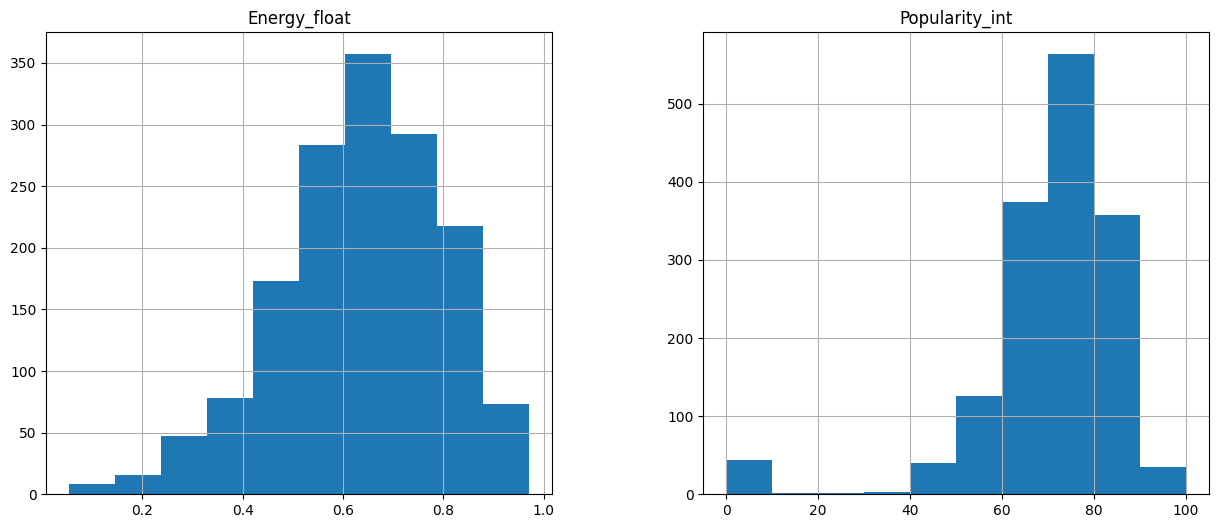

In [ ]:
spotify_4.hist(figsize=(15,6));
plt.savefig('mvp1.png')

I don't have extreme values on my two variables

## Decision Tree Regression

In [ ]:
X = spotify_4[['Energy_float']]
y = spotify_4['Popularity_int']

X.shape, y.shape

((1545, 1), (1545,))

In [ ]:
numLoops = 100

rms_error = np.zeros(numLoops)

for idx in range(0,numLoops):
  X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)
  model = DecisionTreeRegressor(max_depth=3)         # Arbitrarily choosing max_depth of 3
  model.fit(X_train,y_train)
  y_pred = model.predict(X_test)
  rms_error[idx] = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"CV RMSE: {rms_error.mean().round(2)}")


CV RMSE: 15.92


(array([ 4.,  4., 10.,  8., 17., 21., 15.,  8.,  7.,  6.]),
 array([12.9178866 , 13.48889983, 14.05991306, 14.63092629, 15.20193953,
        15.77295276, 16.34396599, 16.91497923, 17.48599246, 18.05700569,
        18.62801892]),
 <BarContainer object of 10 artists>)

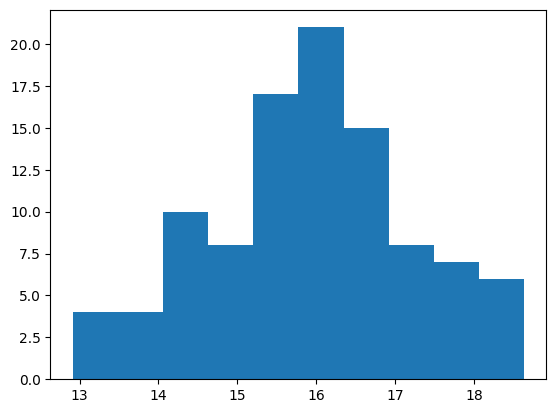

In [ ]:
plt.hist(rms_error)

## How do we choose the tree depth?

In [ ]:
max_depths = [1,2,3,4,5,6,7,8,9,10]
rms_depth = np.zeros(len(max_depths))
std_depth = np.zeros(len(max_depths))

numLoops = 100

for n, depth in enumerate(max_depths):
  rms_error = np.zeros(numLoops)

  for idx in range(0,numLoops):
    X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)
    model = DecisionTreeRegressor(max_depth=depth)
    model.fit(X_train,y_train)
    y_pred = model.predict(X_test)
    rms_error[idx] = np.sqrt(mean_squared_error(y_test, y_pred))

  rms_depth[n] = rms_error.mean()
  std_depth[n] = rms_error.std( ddof = 1 )


In [ ]:
pd.DataFrame( zip( max_depths, rms_depth, std_depth ) )


,0,1,2
0,1,15.426503,1.391442
1,2,15.525221,1.427379
2,3,15.821753,1.309414
3,4,16.320980,1.376327
4,5,16.418254,1.224839
5,6,16.452496,1.272006
6,7,17.194243,1.335074
7,8,16.964827,1.390636
8,9,17.359088,1.419301
9,10,17.658481,1.466718


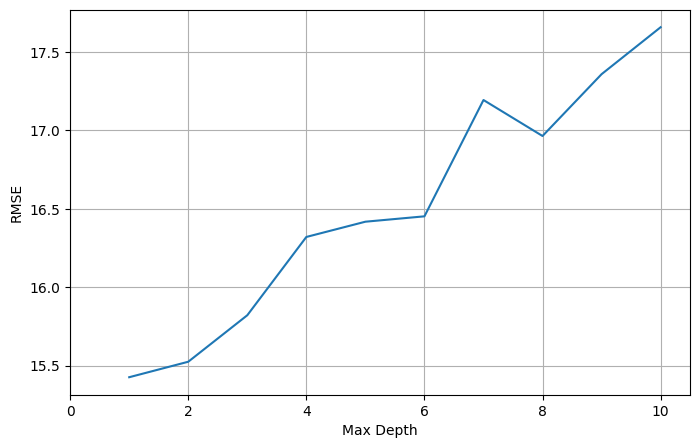

In [ ]:
# Plot result
plt.figure(figsize = (8,5))
plt.plot(max_depths, rms_depth)
plt.xlabel('Max Depth')
plt.ylabel('RMSE')
plt.xlim(0, 10.5)
plt.grid()


In [ ]:
# Re run with max depth = 2
numLoops = 500

rms_error = np.zeros( numLoops )

for idx in range( 0, numLoops ):
  X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2 )
  model = DecisionTreeRegressor( max_depth=2 )
  model.fit( X_train, y_train )
  y_pred = model.predict( X_test )
  rms_error[idx] = np.sqrt( mean_squared_error( y_test, y_pred ) )

print(f"CV RMSE: {rms_error.mean().round(2)}")


CV RMSE: 15.72


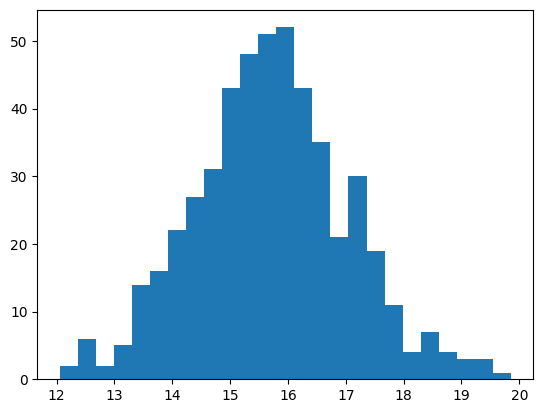

In [ ]:
plt.hist(rms_error, bins = 25);

# Visualize the Decision Tree

In [ ]:
import graphviz
from IPython.display import display
from sklearn import tree

In [ ]:
X_train.shape

(1236, 1)

In [ ]:
spotify_train = X_train.join(y_train)
spotify_train

,Energy_float,Popularity_int
640,0.375,49
1342,0.707,59
1158,0.877,71
1374,0.671,78
184,0.264,84
...,...,...
123,0.425,86
25,0.443,92
234,0.739,82
84,0.593,87


In [ ]:
spotify_train.describe()

,Energy_float,Popularity_int
count,1236.000000,1236.000000
mean,0.630663,70.080097
std,0.162694,15.654495
min,0.054000,0.000000
25%,0.528000,65.000000
50%,0.640500,73.000000
75%,0.747250,79.000000
max,0.970000,100.000000


In [ ]:
16.019**2

256.60836099999995

In [ ]:
spotify_train.query('Energy_float > 0.226').describe()

,Energy_float,Popularity_int
count,1215.000000,1215.000000
mean,0.638742,70.441152
std,0.151810,15.221742
min,0.228000,0.000000
25%,0.535500,65.000000
50%,0.646000,73.000000
75%,0.749500,79.000000
max,0.970000,100.000000


In [ ]:
26.009896**2

676.5146899308161

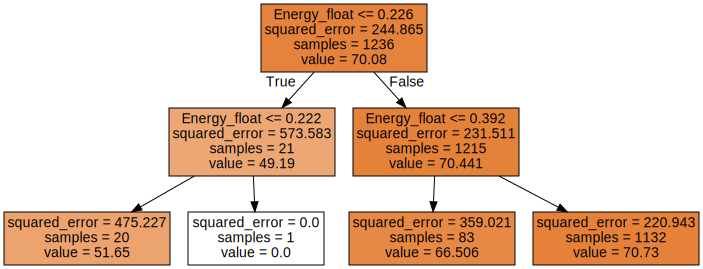

In [ ]:
# Option 1
display(
  graphviz.Source(
    tree.export_graphviz(
      model,
      feature_names = X.columns,
      filled = True,
    )
  )
)


### What Energy would a song have to have in order to have a popularity rating of at least 70.73?  

### > 0.392

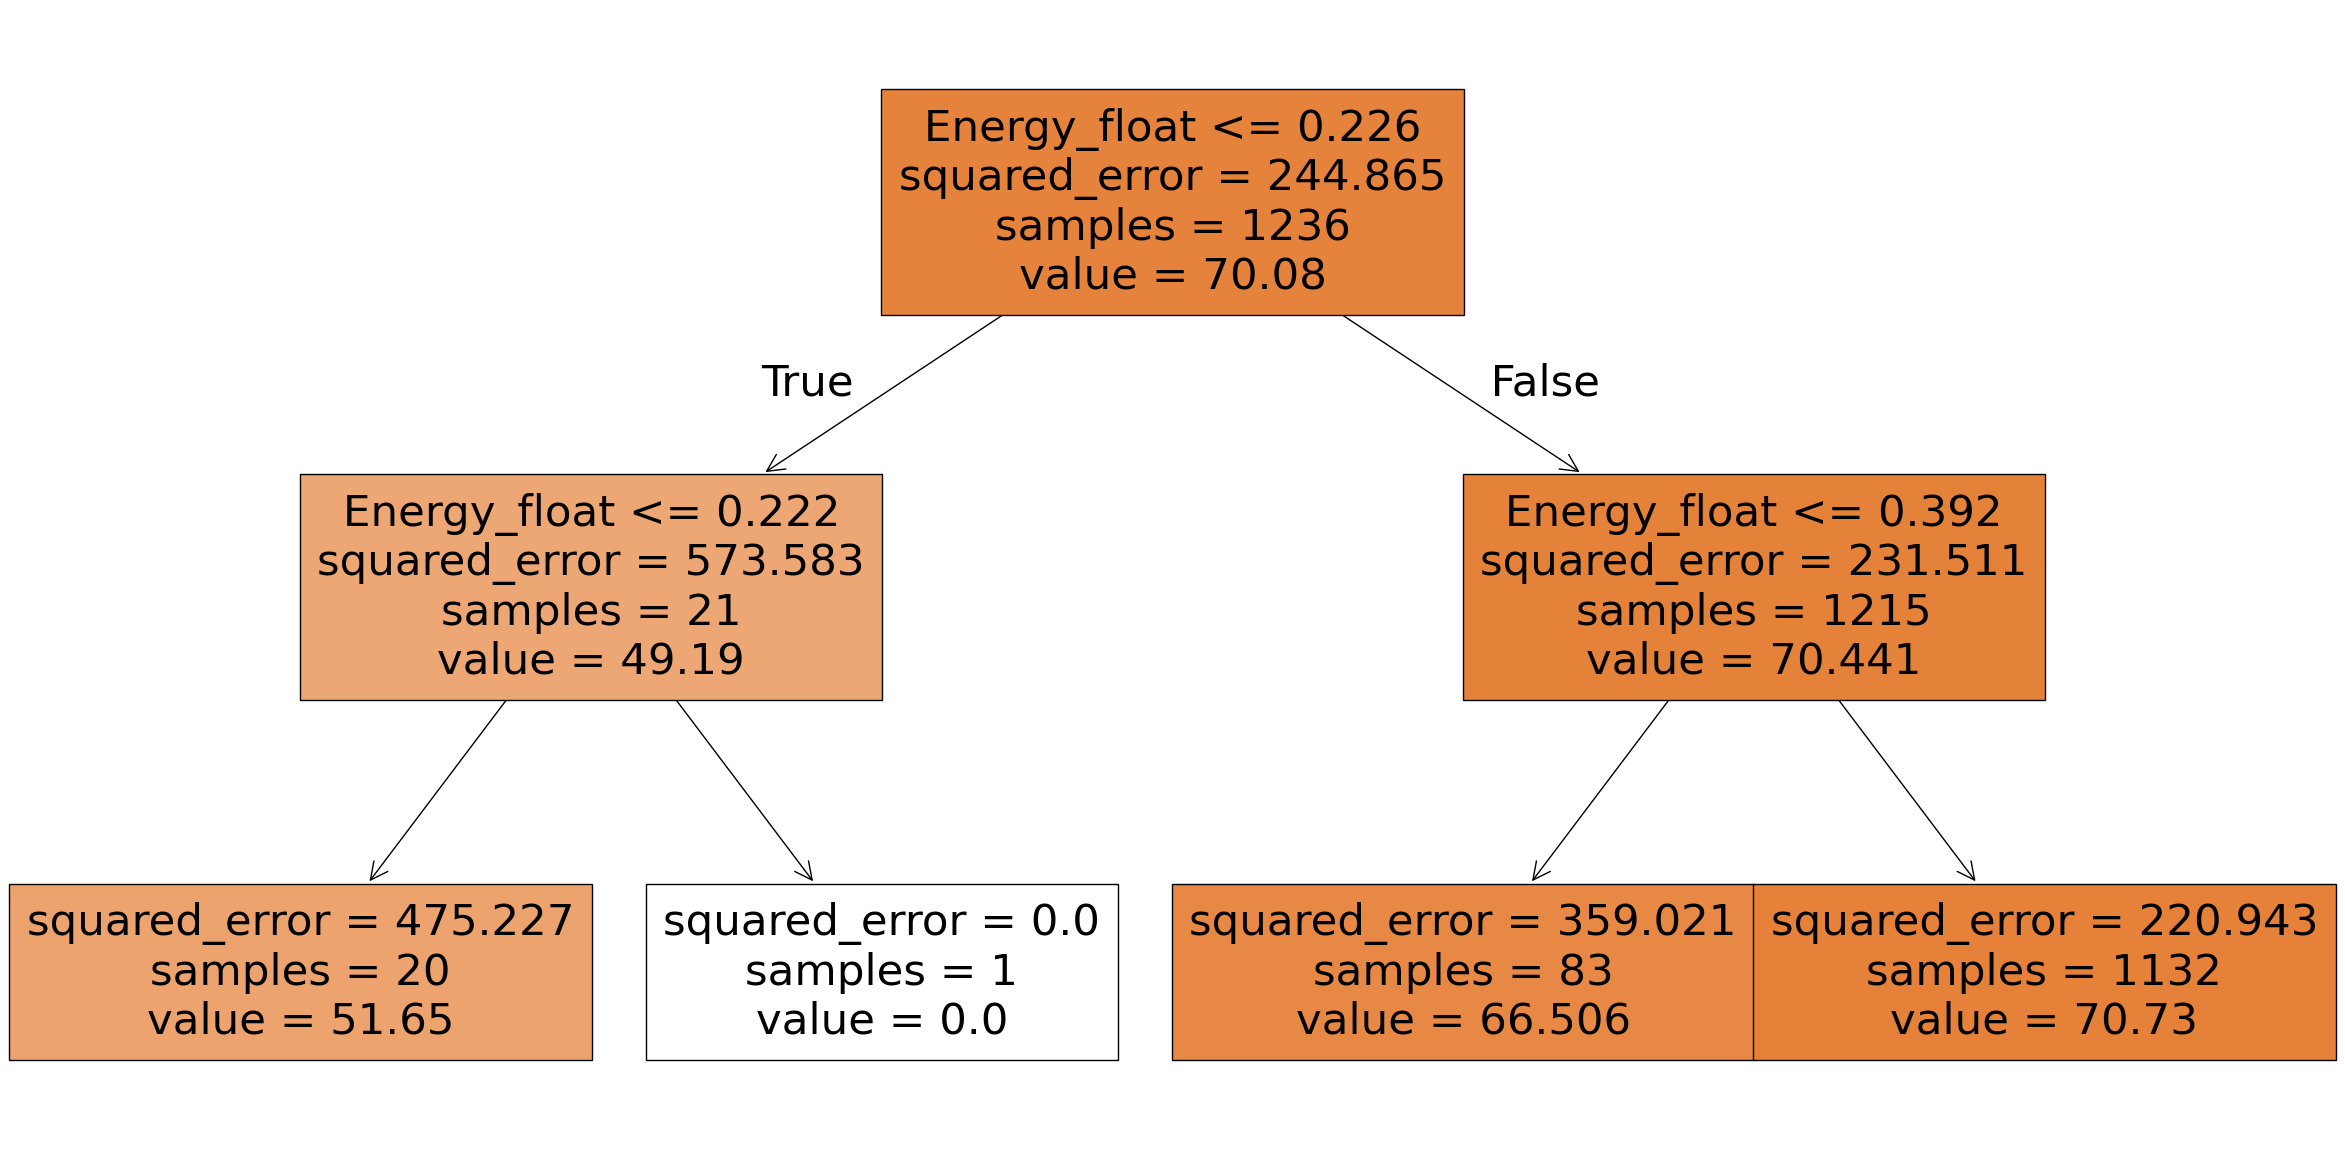

In [ ]:
# Option 2
plt.figure(figsize=(30,15))
tree_plot = tree.plot_tree(
  model,
  feature_names = X.columns,
  filled=True,
)


## Find Important Predictors

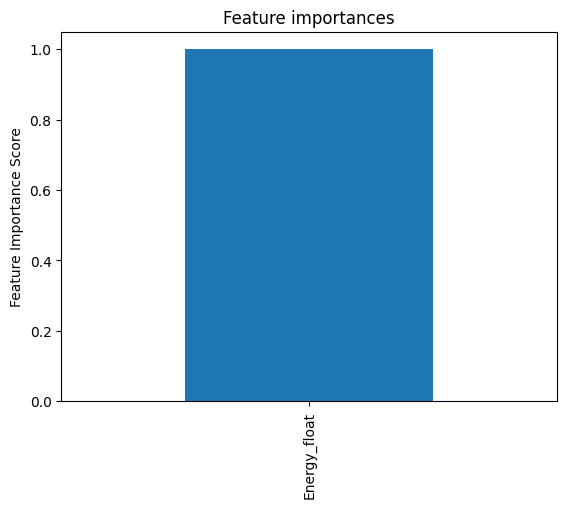

In [ ]:
importances = model.feature_importances_
tree_importances = pd.Series( importances, index = X.columns )

plt.figure()
# tree_importances.plot.bar()
tree_importances.sort_values( ascending = False ).plot.bar()
plt.title("Feature importances")
plt.ylabel('Feature Importance Score') ;


In [ ]:
( tree_importances.sort_values( ascending = False ) * 100 ).cumsum()


,0
Energy_float,100.0
